# Previsão de Risco de Empréstimo com Machine Learning

Este projeto tem como objetivo construir um modelo de Machine Learning capaz de prever se um cliente apresenta risco de inadimplência em uma solicitação de empréstimo.

A variável alvo do projeto é `Risk_Flag`.

- `0` = Cliente de baixo risco
- `1` = Cliente de alto risco

Durante o projeto serão aplicadas etapas de análise exploratória, limpeza de dados, análise de distribuição, tratamento de variáveis categóricas, criação de pipeline e treinamento de modelo supervisionado.

## 1. Importação das Bibliotecas

Nesta etapa importamos as bibliotecas necessárias para manipulação dos dados, visualização gráfica e construção do modelo de Machine Learning.

In [1]:
import pandas as pd

print(pd.__version__)

3.0.3


In [2]:
# Biblioteca utilizada para manipulação e análise de dados em formato de tabela.
import pandas as pd

# Biblioteca utilizada para operações numéricas e cálculos matemáticos.
import numpy as np

# Biblioteca utilizada para criação de gráficos.
import matplotlib.pyplot as plt

# Biblioteca utilizada para criação de gráficos estatísticos mais elaborados.
import seaborn as sns

# 2. Carregamento do Dataset

Nesta etapa carregamos o conjunto de dados que será utilizado para treinamento e análise do modelo de Machine Learning.

In [3]:
# Carregamento do dataset
df = pd.read_csv("Loan Prediction.csv")

# Exibição das primeiras linhas
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


# 3. Estrutura Inicial dos Dados

Antes de iniciar a modelagem, é importante compreender o tamanho do dataset, os tipos de dados presentes e a quantidade de registros disponíveis.

In [ ]:
# Quantidade de linhas e colunas
df.shape

(252000, 13)

In [5]:
# Informações gerais do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Id                 252000 non-null  int64
 1   Income             252000 non-null  int64
 2   Age                252000 non-null  int64
 3   Experience         252000 non-null  int64
 4   Married/Single     252000 non-null  str  
 5   House_Ownership    252000 non-null  str  
 6   Car_Ownership      252000 non-null  str  
 7   Profession         252000 non-null  str  
 8   CITY               252000 non-null  str  
 9   STATE              252000 non-null  str  
 10  CURRENT_JOB_YRS    252000 non-null  int64
 11  CURRENT_HOUSE_YRS  252000 non-null  int64
 12  Risk_Flag          252000 non-null  int64
dtypes: int64(7), str(6)
memory usage: 25.0 MB


In [9]:
# As principais métricas apresentadas são:
#
# count -> quantidade de registros
# mean  -> média
# std   -> desvio padrão
# min   -> menor valor
# 25%   -> primeiro quartil
# 50%   -> mediana
# 75%   -> terceiro quartil
# max   -> maior valor
#
# Essa etapa ajuda a compreender o comportamento
# geral dos dados antes da modelagem.

df.describe()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,126000.500000,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,72746.278255,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,63000.750000,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,126000.500000,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,189000.250000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,252000.000000,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


# 4. Verificação de Valores Nulos

Valores ausentes podem impactar o treinamento do modelo. Nesta etapa verificamos a existência de dados faltantes.

In [10]:
# Verifica se existem valores ausentes (nulos)
# em alguma coluna do dataset.
#
# Valores nulos podem prejudicar o treinamento
# do modelo de Machine Learning.
#
# Como resultado esperado, todas as colunas
# devem apresentar valor 0.

df.isnull().sum()

Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64

# 5. Análise da Variável Alvo

A variável alvo do projeto é `Risk_Flag`, responsável por indicar se um cliente apresenta ou não risco de inadimplência.

Nesta etapa analisamos a distribuição das classes para verificar se o dataset está balanceado ou desbalanceado, informação importante para o treinamento e avaliação do modelo.

In [14]:
# Conta a quantidade de clientes existentes em cada classe.
#
# Risk_Flag = 0 -> Cliente de baixo risco
# Risk_Flag = 1 -> Cliente de alto risco
#
# Esta análise permite identificar a distribuição
# inicial dos dados.

df['Risk_Flag'].value_counts()

Risk_Flag
0    221004
1     30996
Name: count, dtype: int64

In [15]:
# Calcula o percentual de clientes em cada classe.
#
# normalize=True converte a contagem em proporção.
# Multiplicamos por 100 para exibir em porcentagem.
#
# Essa análise é importante para verificar se existe
# desbalanceamento entre as classes.

df['Risk_Flag'].value_counts(normalize=True) * 100

Risk_Flag
0    87.7
1    12.3
Name: proportion, dtype: float64

## Distribuição das Classes

Além dos valores numéricos, é importante visualizar graficamente a distribuição da variável alvo para facilitar a interpretação dos resultados.

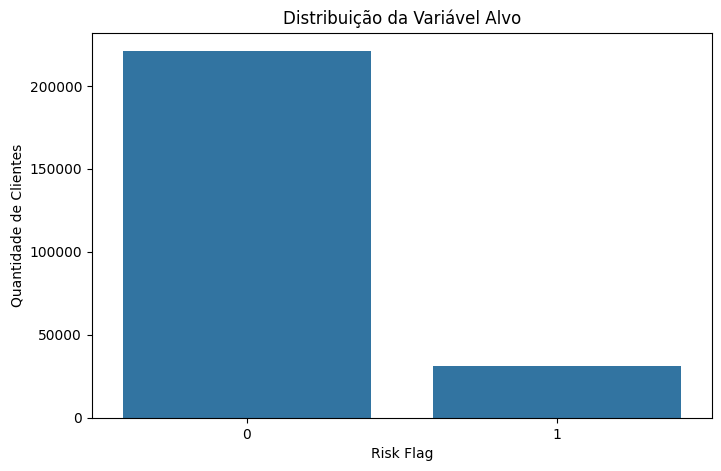

In [16]:
# Cria uma área de desenho para o gráfico.
plt.figure(figsize=(8,5))

# Gera um gráfico de barras mostrando a quantidade
# de clientes em cada classe da variável alvo.
sns.countplot(
    data=df,
    x='Risk_Flag'
)

# Define o título do gráfico.
plt.title('Distribuição da Variável Alvo')

# Nome do eixo horizontal.
plt.xlabel('Risk Flag')

# Nome do eixo vertical.
plt.ylabel('Quantidade de Clientes')

# Exibe o gráfico.
plt.show()

### Conclusão

Observou-se que aproximadamente 87,7% dos clientes pertencem à classe de baixo risco (Risk_Flag = 0), enquanto apenas 12,3% pertencem à classe de alto risco (Risk_Flag = 1).

Esse resultado demonstra que o dataset apresenta desbalanceamento entre as classes, característica que deverá ser considerada durante a avaliação do modelo de Machine Learning.

# 6. Análise das Variáveis Numéricas

Nesta etapa analisamos a distribuição das principais variáveis numéricas presentes no dataset.

O objetivo é compreender o comportamento dos dados, identificar possíveis padrões, concentrações de valores e possíveis anomalias que possam impactar o treinamento do modelo.

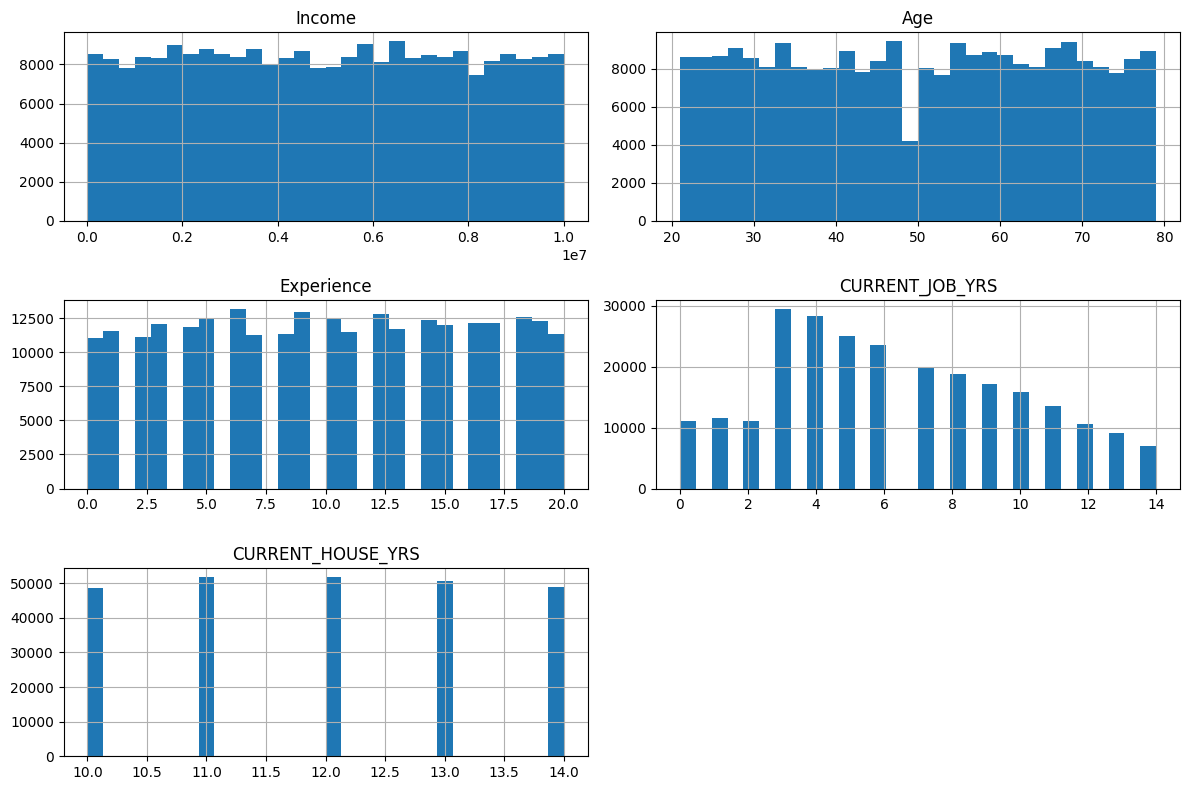

In [17]:
# Seleciona as principais variáveis numéricas do dataset
# e gera histogramas para visualizar sua distribuição.

df[['Income',
    'Age',
    'Experience',
    'CURRENT_JOB_YRS',
    'CURRENT_HOUSE_YRS']].hist(
        figsize=(12,8),
        bins=30
)

# Ajusta automaticamente o espaçamento dos gráficos.
plt.tight_layout()

# Exibe os histogramas.
plt.show()

## Interpretação dos Histogramas

Os histogramas permitem visualizar como os valores estão distribuídos ao longo do dataset.

As variáveis analisadas foram:

- Income (Renda anual)
- Age (Idade)
- Experience (Anos de experiência profissional)
- CURRENT_JOB_YRS (Tempo no emprego atual)
- CURRENT_HOUSE_YRS (Tempo na residência atual)

Através dessa análise é possível compreender o perfil geral dos clientes presentes na base de dados.

# 7. Análise de Outliers

Outliers são valores muito diferentes da maioria dos registros.

Esses valores podem influenciar o treinamento do modelo e, por esse motivo, devem ser investigados antes da etapa de modelagem.

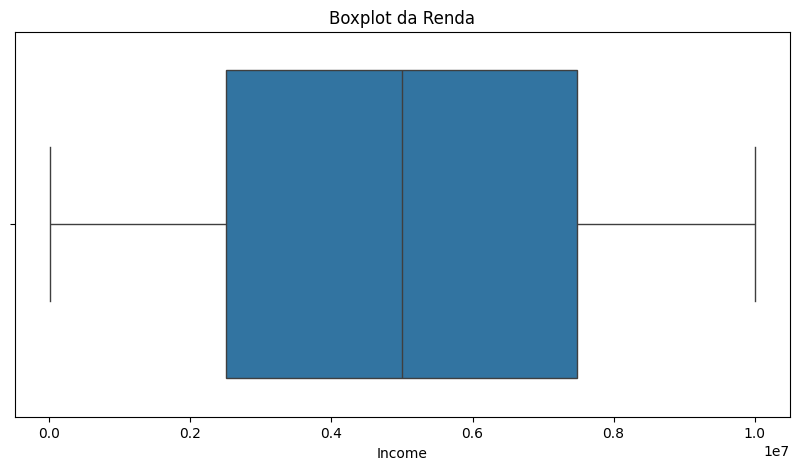

In [18]:
# Cria um boxplot para analisar a distribuição
# da renda dos clientes.

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Income']
)

plt.title('Boxplot da Renda')

plt.xlabel('Income')

plt.show()

## Interpretação do Boxplot

O boxplot permite visualizar:

- Mediana dos dados
- Quartis
- Amplitude dos valores
- Possíveis outliers

Durante a análise não foram observados outliers extremos relevantes na variável Income.

# 8. Relação entre Renda e Risco

Nesta etapa comparamos a distribuição da renda entre clientes classificados como baixo risco e alto risco.

O objetivo é verificar se existe alguma diferença significativa entre os grupos.

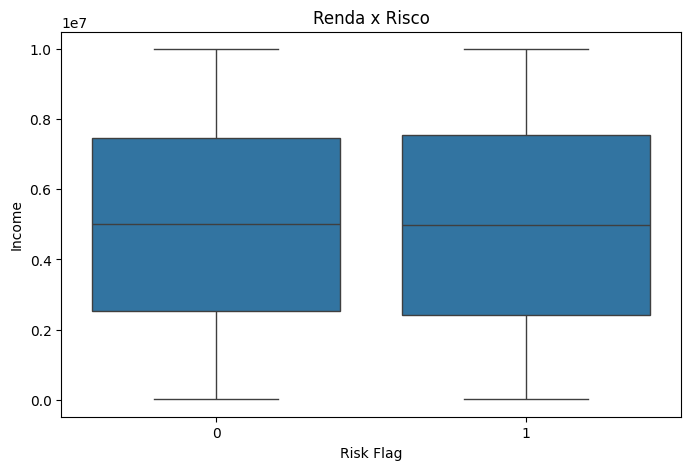

In [19]:
# Compara a distribuição da renda entre as classes
# da variável alvo.

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Risk_Flag',
    y='Income'
)

plt.title('Renda x Risco')

plt.xlabel('Risk Flag')

plt.ylabel('Income')

plt.show()

## Interpretação

Observou-se que os clientes classificados como alto risco e baixo risco apresentam distribuições de renda bastante semelhantes.

Isso indica que a variável Income, isoladamente, não parece ser suficiente para explicar o risco de inadimplência.

# 9. Matriz de Correlação

A correlação mede o grau de relacionamento entre duas variáveis numéricas.

Seu valor varia entre:

- -1 → Correlação negativa forte
- 0 → Sem correlação
- +1 → Correlação positiva forte

O objetivo desta análise é identificar possíveis relações entre as variáveis do dataset e compreender quais atributos possuem maior associação entre si.

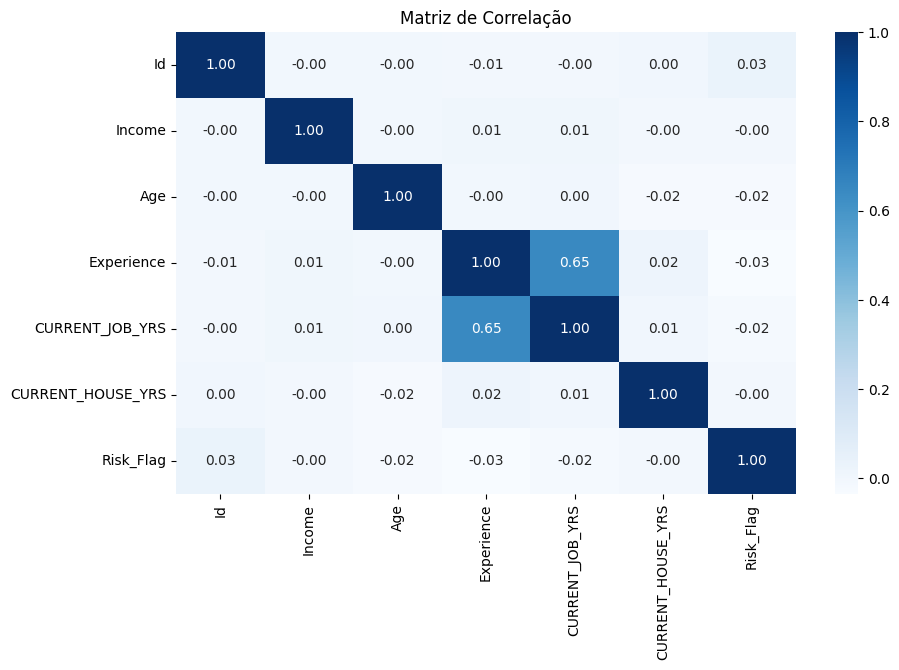

In [20]:
# Seleciona apenas as colunas numéricas do dataset.
numeric_columns = df.select_dtypes(include='number')

# Calcula a matriz de correlação.
correlation_matrix = numeric_columns.corr()

# Define o tamanho da figura.
plt.figure(figsize=(10,6))

# Cria o mapa de calor da correlação.
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

# Define o título do gráfico.
plt.title('Matriz de Correlação')

# Exibe o gráfico.
plt.show()

## Interpretação da Matriz de Correlação

Durante a análise foi possível observar que a maior correlação encontrada ocorreu entre as variáveis:

- Experience
- CURRENT_JOB_YRS

Essa relação é esperada, pois clientes com maior experiência profissional tendem a permanecer mais tempo em seus empregos atuais.

Também foi observado que a variável alvo (Risk_Flag) apresenta baixa correlação linear com as demais variáveis numéricas.

Esse comportamento sugere que o modelo de Machine Learning precisará aprender padrões mais complexos utilizando múltiplos atributos simultaneamente.

# 10. Análise das Variáveis Categóricas

As variáveis categóricas representam características descritivas dos clientes.

Nesta etapa analisaremos a distribuição das principais categorias presentes no dataset.

In [21]:
# Conta a quantidade de clientes por estado civil.

df['Married/Single'].value_counts()

Married/Single
single     226272
married     25728
Name: count, dtype: int64

In [22]:
# Conta a quantidade de clientes por tipo de propriedade.

df['House_Ownership'].value_counts()

House_Ownership
rented          231898
owned            12918
norent_noown      7184
Name: count, dtype: int64

In [23]:
# Conta quantos clientes possuem ou não veículo.

df['Car_Ownership'].value_counts()

Car_Ownership
no     176000
yes     76000
Name: count, dtype: int64

In [24]:
# Exibe as 10 profissões mais frequentes do dataset.

df['Profession'].value_counts().head(10)

Profession
Physician                     5957
Statistician                  5806
Web_designer                  5397
Psychologist                  5390
Computer_hardware_engineer    5372
Drafter                       5359
Magistrate                    5357
Fashion_Designer              5304
Air_traffic_controller        5281
Comedian                      5259
Name: count, dtype: int64

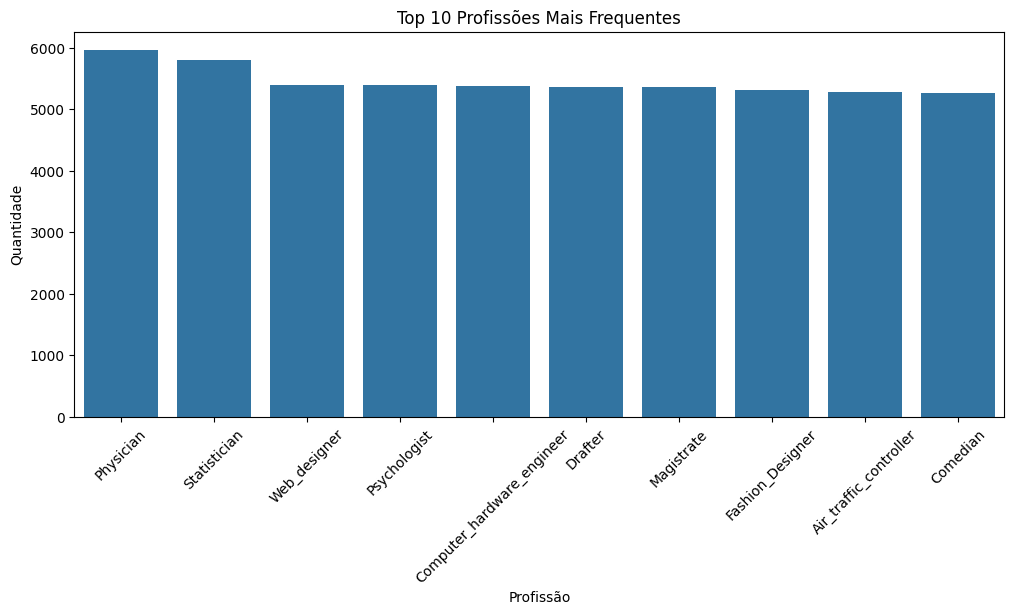

In [25]:
# Seleciona as 10 profissões mais frequentes.

top_professions = df['Profession'].value_counts().head(10)

# Define o tamanho da figura.

plt.figure(figsize=(12,5))

# Cria gráfico de barras.

sns.barplot(
    x=top_professions.index,
    y=top_professions.values
)

# Rotaciona os nomes das profissões.

plt.xticks(rotation=45)

plt.title('Top 10 Profissões Mais Frequentes')

plt.xlabel('Profissão')

plt.ylabel('Quantidade')

plt.show()

## Interpretação

Observou-se que as profissões estão distribuídas de forma relativamente equilibrada no dataset.

As profissões mais frequentes foram:

- Physician (Médico)
- Statistician (Estatístico)

Entretanto, a diferença entre as categorias é pequena, indicando que não existe concentração excessiva em uma única profissão.

Essa característica é positiva para o treinamento do modelo, pois reduz possíveis vieses relacionados à profissão dos clientes.

# 11. Preparação dos Dados para Machine Learning

Nesta etapa preparamos os dados para treinamento do modelo.

O algoritmo de Machine Learning não consegue trabalhar diretamente com textos, portanto será necessário transformar as variáveis categóricas em valores numéricos.

Também iremos separar os atributos de entrada (Features) da variável alvo (Target).

In [26]:
# Cria uma cópia do dataset original
# para evitar alterações acidentais.

df_ml = df.copy()

In [27]:
# Variável alvo do projeto.
#
# Risk_Flag:
# 0 = Baixo risco
# 1 = Alto risco

y = df_ml['Risk_Flag']

In [28]:
# Remove a variável alvo das entradas.
#
# As variáveis restantes serão utilizadas
# para realizar as previsões.

X = df_ml.drop('Risk_Flag', axis=1)

In [29]:
# Exibe o formato das variáveis.
#
# X = atributos de entrada
# y = variável alvo

print("Features:", X.shape)
print("Target:", y.shape)

Features: (252000, 12)
Target: (252000,)


In [30]:
from sklearn.model_selection import train_test_split

# 12. Divisão dos Dados em Treino e Teste

Antes de treinar o modelo, é necessário separar os dados em dois grupos:

- Treino: utilizado para ensinar o algoritmo.
- Teste: utilizado para avaliar o desempenho do modelo em dados que ele nunca viu.

Neste projeto utilizaremos:

- 80% dos dados para treinamento
- 20% dos dados para teste

In [31]:
# Importa a função responsável pela divisão dos dados.

from sklearn.model_selection import train_test_split

In [32]:
# Divide os dados em treino e teste.
#
# test_size=0.2 -> 20% para teste
# random_state=42 -> garante reprodutibilidade

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
# Exibe o tamanho dos conjuntos gerados.

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (201600, 12)
Teste: (50400, 12)


# 13. Transformação das Variáveis Categóricas

Algoritmos de Machine Learning trabalham apenas com números.

Como nosso dataset possui colunas de texto, será necessário transformá-las em valores numéricos utilizando One Hot Encoding.

In [34]:
# Importa o OneHotEncoder.

from sklearn.preprocessing import OneHotEncoder

In [35]:
# Importa ColumnTransformer.
#
# Essa ferramenta permite aplicar diferentes
# transformações para diferentes tipos de coluna.

from sklearn.compose import ColumnTransformer

In [36]:
# Identifica automaticamente as colunas categóricas.

categorical_columns = X.select_dtypes(include='object').columns

print(categorical_columns)

Index(['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession',
       'CITY', 'STATE'],
      dtype='str')


C:\Users\igor\AppData\Local\Temp\ipykernel_3304\3979077151.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include='object').columns


In [37]:
# Cria o transformador para converter textos
# em valores numéricos.

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_columns
        )
    ],
    remainder='passthrough'
)

# 14. Treinamento do Modelo

Nesta etapa treinaremos um modelo Random Forest.

O Random Forest é um algoritmo supervisionado baseado em múltiplas árvores de decisão e é amplamente utilizado em problemas de classificação.

In [38]:
# Importa o Random Forest.

from sklearn.ensemble import RandomForestClassifier

In [39]:
# Importa Pipeline.
#
# O Pipeline organiza todas as etapas do
# processo em um único fluxo.

from sklearn.pipeline import Pipeline

In [40]:
# Cria o pipeline completo.
#
# 1. Converte textos para números.
# 2. Treina o Random Forest.

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [ ]:
# Treina o modelo utilizando os dados de treino.
#
# Durante esta etapa o algoritmo aprende padrões
# existentes nos dados históricos.
#
# O Random Forest cria múltiplas árvores de decisão
# e combina seus resultados para gerar previsões
# mais robustas e precisas.

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

# 15. Realização das Previsões

Após o treinamento, utilizamos o conjunto de teste para verificar a capacidade do modelo em prever corretamente clientes de alto e baixo risco.

In [42]:
# Utiliza o modelo treinado para realizar previsões
# nos dados de teste.

y_pred = model.predict(X_test)

In [43]:
# Exibe as primeiras previsões realizadas.

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# 16. Avaliação do Modelo

Nesta etapa avaliamos o desempenho do algoritmo utilizando métricas de classificação.

In [44]:
# Importa as métricas de avaliação.

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [45]:
# Calcula a acurácia do modelo.

accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")

Acurácia: 0.9011


In [46]:
# Gera a matriz de confusão.

cm = confusion_matrix(y_test, y_pred)

cm

array([[42543,  1604],
       [ 3381,  2872]])

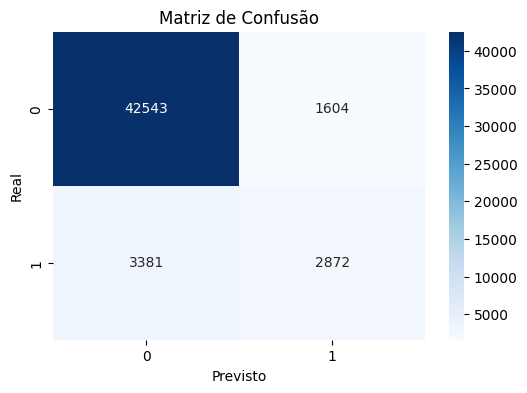

In [47]:
# Exibe a matriz de confusão em formato gráfico.

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão')

plt.xlabel('Previsto')

plt.ylabel('Real')

plt.show()

In [48]:
# Exibe métricas detalhadas do modelo.

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94     44147
           1       0.64      0.46      0.54      6253

    accuracy                           0.90     50400
   macro avg       0.78      0.71      0.74     50400
weighted avg       0.89      0.90      0.89     50400



# 17. Conclusão

Foi desenvolvido um modelo de Machine Learning utilizando o algoritmo Random Forest para prever o risco de inadimplência de clientes.

Durante o projeto foram realizadas etapas de:

- Importação dos dados
- Análise exploratória
- Visualização gráfica
- Análise de correlação
- Tratamento de variáveis categóricas
- Divisão dos dados em treino e teste
- Treinamento do modelo
- Avaliação dos resultados

O modelo alcançou aproximadamente 90% de acurácia no conjunto de teste.

Observou-se que o algoritmo apresentou excelente desempenho para identificação de clientes de baixo risco e desempenho moderado para identificação de clientes de alto risco.

O principal desafio encontrado foi o desbalanceamento das classes, já que apenas 12,3% dos clientes pertencem à categoria de alto risco.

Mesmo assim, os resultados demonstram que técnicas de Machine Learning podem ser utilizadas para auxiliar instituições financeiras na análise de risco e apoio à tomada de decisão.